# Introduction to Key Libraries for Regression Problems

In this notebook, we will explore the fundamental libraries used for regression problems in Python. 
We will generate a dummy dataset, visualize the correlation between features, train a simple Linear Regression model, and evaluate its performance using standard metrics.

We will also introduce two important evaluation metrics:
- **Mean Squared Error (MSE)**: Measures the average squared difference between actual and predicted values. A lower MSE indicates a better fit.
- **R-squared (R²) Score**: Represents how well the independent variables explain the variance in the target variable. A value closer to 1 indicates a better fit.

  The formula for R² is:
  
$$ R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} $$
  
Where:
$$
y_i \text{ are the actual values}
$$
$$
\hat{y}_i \text{ are the predicted values}
$$
$$
\bar{y} \text{ is the mean of the actual values}
$$

In [2]:
import numpy as np  # Numerical computing
import pandas as pd  # Data manipulation
import matplotlib.pyplot as plt  # Data visualization
import seaborn as sns  # Advanced data visualization
from sklearn.model_selection import train_test_split  # Splitting dataset
from sklearn.preprocessing import StandardScaler  # Data scaling
from sklearn.linear_model import LinearRegression  # Linear Regression model
from sklearn.metrics import mean_squared_error, r2_score  # Evaluation metrics

,Feature1,Feature2,Feature3,Target
0,3.745401,0.314292,6.420316,11.327347
1,9.507143,6.364104,0.841400,27.218228
2,7.319939,3.143560,1.616287,26.247706
3,5.986585,5.085707,8.985542,19.227593
4,1.560186,9.075665,6.064291,0.630274


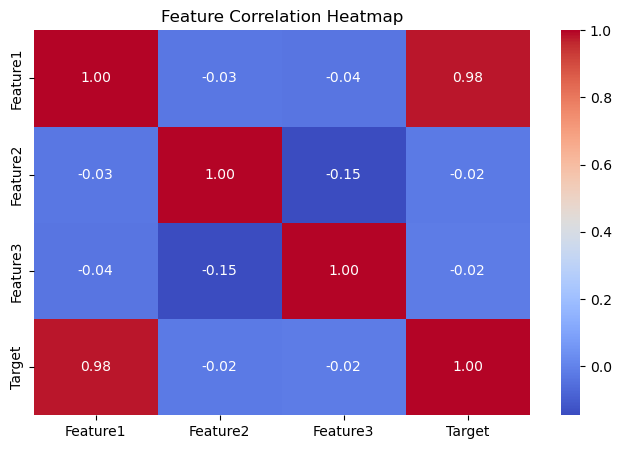

Mean Squared Error: 8.41
R-squared: 0.91


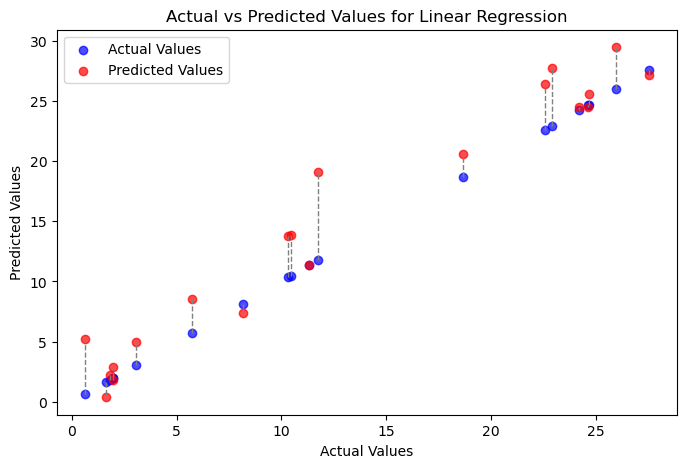

In [7]:
np.random.seed(42)
n_samples = 100

X1 = np.random.rand(n_samples) * 10 
X2 = np.random.rand(n_samples) * 10 
X3 = np.random.rand(n_samples) * 10 
Y = X1 * 3 + np.random.normal(0, 2, n_samples) 

df = pd.DataFrame({'Feature1': X1, 'Feature2': X2, 'Feature3': X3, 'Target': Y})

display(df.head())

plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

X = df[['Feature1', 'Feature2', 'Feature3']]
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_test, color='blue', label='Actual Values', alpha=0.7)
plt.scatter(y_test, y_pred, color='red', label='Predicted Values', alpha=0.7)

for actual, predicted in zip(y_test, y_pred):
    plt.plot([actual, actual], [actual, predicted], color='gray', linestyle='dashed', linewidth=1)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values for Linear Regression")
plt.legend()
plt.show()